## **Part A — Profiling, cleaning, and the data story**

In [42]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib


In [4]:
df=sns.load_dataset("titanic")

In [5]:
df.to_csv("titanic.csv", index=False)

In [7]:
print("\nShape:", df.shape)
print("\nInfo:")
df.info()

print("\nDescribe:")
display(df.describe(include="all").T)

missing = (
    df.isna().sum()
      .loc[lambda s: s > 0]
      .to_frame("missing_count")
)
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(2)

print("\nMissing-value report:")
display(missing)


Shape: (891, 15)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

Describe:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing-value report:


,missing_count,missing_pct
age,177,19.87
embarked,2,0.22
deck,688,77.22
embark_town,2,0.22


### Missing-value decisions

The threshold rule is applied per affected column:

- Under 5% missing → drop affected rows.
- 5%–30% missing → impute.
- Very high missingness → explicitly drop the column or encode missing as its own category.

The code below reports the exact measured percentage before applying each decision.

In [17]:
missing_pct = (df.isna().mean() * 100).round(2)

print("Exact missing percentages for affected columns:")
for col, pct in missing_pct[missing_pct > 0].items():
    print(f"{col}: {pct:.2f}%")

# age: 5%-30% missing -> median imputation.
# Check if 'age' column exists and has missing values reported in missing_pct
if "age" in df.columns and "age" in missing_pct and missing_pct["age"] > 0:
    age_missing_pct = missing_pct["age"]
    age_median = df["age"].median()
    df["age"] = df["age"].fillna(age_median)
    print(f"\nage: {age_missing_pct:.2f}% -> median imputation using {age_median:.2f}.")
elif "age" in df.columns and df["age"].isna().any():
    # Fallback if missing_pct was cleaned up, but 'age' still has NaNs
    age_median = df["age"].median()
    df["age"] = df["age"].fillna(age_median)
    print(f"\nage: missing values in 'age' (percentage unknown from current missing_pct) -> median imputation using {age_median:.2f}.")

# embarked and embark_town: under 5% missing -> drop affected rows.
low_missing_cols_to_process = []
for col_name in ["embarked", "embark_town"]:
    if col_name in df.columns and col_name in missing_pct and missing_pct[col_name] > 0:
        low_missing_cols_to_process.append(col_name)
    elif col_name in df.columns and df[col_name].isna().any():
        # Fallback for already cleaned missing_pct but still has NaNs
        low_missing_cols_to_process.append(col_name)
        print(f"Warning: Missing percentage for '{col_name}' not in `missing_pct` but NaNs found. Dropping rows.")


if low_missing_cols_to_process:
    df = df.dropna(subset=low_missing_cols_to_process)
    for col_name in low_missing_cols_to_process:
        # Try to print percentage if available, otherwise just say "missing"
        pct_str = f"{missing_pct[col_name]:.2f}%" if col_name in missing_pct else "missing"
        print(f"{col_name}: {pct_str} -> drop affected rows.")

# deck: very high missingness -> drop the column.
if "deck" in df.columns:
    # Only try to get missing percentage if 'deck' is in the current `missing_pct`
    deck_missing_pct_val = missing_pct["deck"] if "deck" in missing_pct else None
    if deck_missing_pct_val is None and "deck" in globals().get("missing", {}).get("index", []):
         # If not in current missing_pct, but available from the `missing` DataFrame from 5JbI-En3L4bF
         deck_missing_pct_val = globals()["missing"].loc["deck", "missing_pct"]

    df = df.drop(columns=["deck"])
    pct_str = f"{deck_missing_pct_val:.2f}%" if deck_missing_pct_val is not None else "unknown percentage"
    print(f"deck: {pct_str} -> drop column because missingness is >30%.")
else:
    # If 'deck' is not in df.columns, it's already dropped.
    # We can still print a message if the original `missing` dataframe had it, for context.
    if "deck" in globals().get("missing", {}).get("index", []):
        deck_missing_pct_val = globals()["missing"].loc["deck", "missing_pct"]
        print(f"deck: {deck_missing_pct_val:.2f}% -> column already dropped in previous step (was >30% missing).")
    else:
        print("deck: column not found (already dropped or never existed).")


print("\nRemaining missing values:")
display(df.isna().sum().loc[lambda s: s > 0])

# Final committed fallback becomes the cleaned dataset used by modeling.
df.to_csv("titanic.csv", index=False)

print("\nCleaned dataset saved to:", "titanic.csv")
print("Cleaned shape:", df.shape)

Exact missing percentages for affected columns:
deck: column not found (already dropped or never existed).

Remaining missing values:


,0



Cleaned dataset saved to: titanic.csv
Cleaned shape: (889, 14)


## 2. Univariate analysis: age and fare

In [24]:
def iqr_outlier_count(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((series < lower) | (series > upper)).sum()
    return count, q1, q3, lower, upper

age_outliers = iqr_outlier_count(df["age"])
fare_outliers = iqr_outlier_count(df["fare"])

print(f"Age IQR outliers: {age_outliers[0]}")
print(f"Fare IQR outliers: {fare_outliers[0]}")

fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode().iloc[0]

print(f"Fare mean: {fare_mean:.4f}")
print(f"Fare median: {fare_median:.4f}")
print(f"Fare mode: {fare_mode:.4f}")

if fare_mean > fare_median > fare_mode:
    fare_shape = "right-skewed"
elif fare_mean < fare_median < fare_mode:
    fare_shape = "left-skewed"
else:
    fare_shape = "approximately symmetric / not strictly ordered"

print("Fare distribution conclusion:", fare_shape)


Age IQR outliers: 65
Fare IQR outliers: 114
Fare mean: 32.0967
Fare median: 14.4542
Fare mode: 8.0500
Fare distribution conclusion: right-skewed


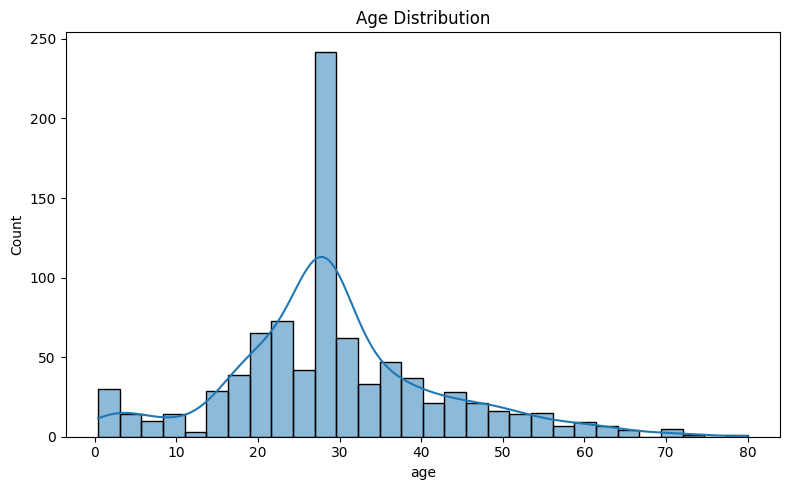

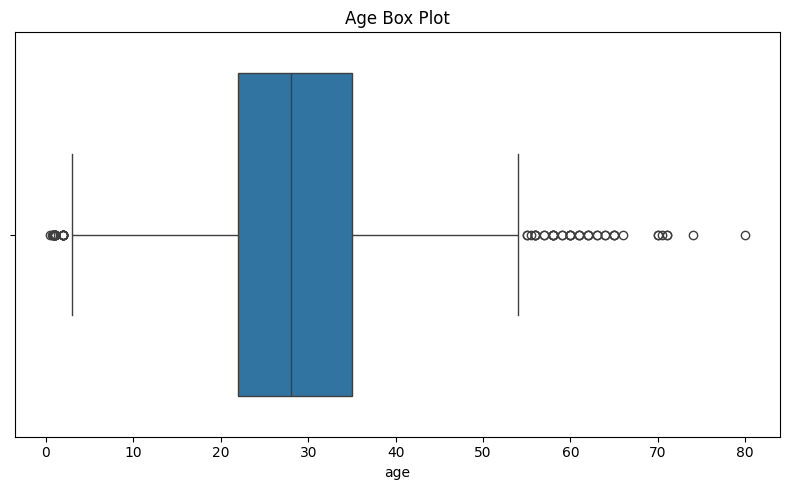

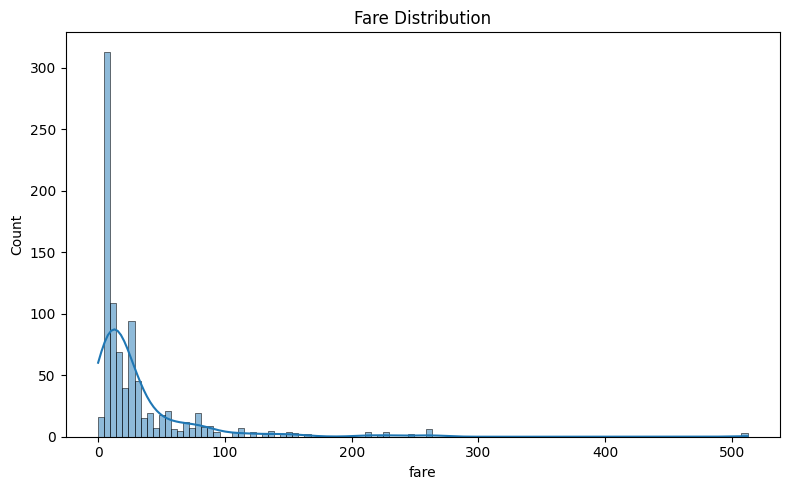

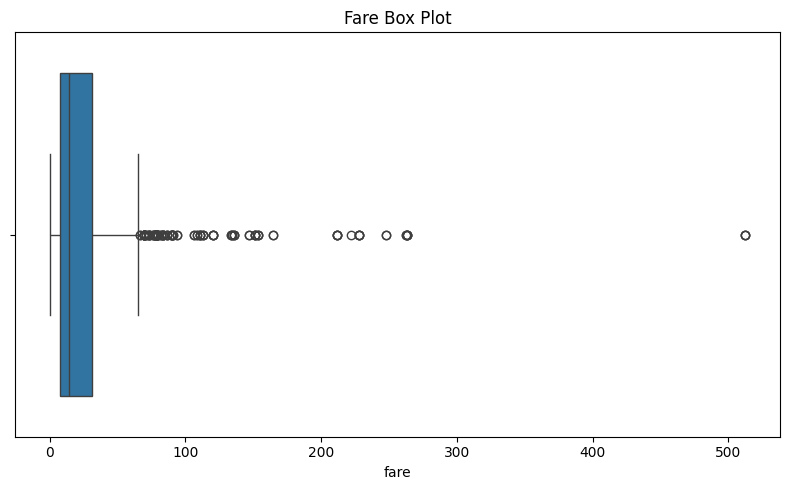

In [26]:
CHART_DIR = Path('charts')
CHART_DIR.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=df, x="age", kde=True, ax=ax)
ax.set_title("Age Distribution")
fig.tight_layout()
fig.savefig(CHART_DIR / "01_age_histogram.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="age", ax=ax)
ax.set_title("Age Box Plot")
fig.tight_layout()
fig.savefig(CHART_DIR / "02_age_boxplot.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=df, x="fare", kde=True, ax=ax)
ax.set_title("Fare Distribution")
fig.tight_layout()
fig.savefig(CHART_DIR / "03_fare_histogram.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="fare", ax=ax)
ax.set_title("Fare Box Plot")
fig.tight_layout()
fig.savefig(CHART_DIR / "04_fare_boxplot.png", dpi=150)
plt.show()

## 3. Bivariate survival analysis

In [20]:
# Required boolean-mask examples using & and |.
female_mask = df["sex"].eq("female")
male_mask = df["sex"].eq("male")
first_or_second_mask = (df["pclass"].eq(1)) | (df["pclass"].eq(2))
female_first_class_mask = (df["sex"].eq("female")) & (df["pclass"].eq(1))

print(f"Female survival rate: {df.loc[female_mask, 'survived'].mean():.4f}")
print(f"Male survival rate: {df.loc[male_mask, 'survived'].mean():.4f}")
print(f"1st or 2nd class survival rate: {df.loc[first_or_second_mask, 'survived'].mean():.4f}")
print(f"Female 1st-class survival rate: {df.loc[female_first_class_mask, 'survived'].mean():.4f}")

survival_by_sex = df.groupby("sex", as_index=False)["survived"].mean()
survival_by_sex["survival_rate_pct"] = survival_by_sex["survived"] * 100
display(survival_by_sex)

survival_by_class = df.groupby("pclass", as_index=False)["survived"].mean()
survival_by_class["survival_rate_pct"] = survival_by_class["survived"] * 100
display(survival_by_class)

survival_by_sex_class = df.groupby(["sex", "pclass"], as_index=False)["survived"].mean()
survival_by_sex_class["survival_rate_pct"] = survival_by_sex_class["survived"] * 100
display(survival_by_sex_class)

Female survival rate: 0.7404
Male survival rate: 0.1889
1st or 2nd class survival rate: 0.5553
Female 1st-class survival rate: 0.9674


,sex,survived,survival_rate_pct
0,female,0.740385,74.038462
1,male,0.188908,18.890815


,pclass,survived,survival_rate_pct
0,1,0.626168,62.616822
1,2,0.472826,47.282609
2,3,0.242363,24.236253


,sex,pclass,survived,survival_rate_pct
0,female,1,0.967391,96.739130
1,female,2,0.921053,92.105263
2,female,3,0.500000,50.000000
3,male,1,0.368852,36.885246
4,male,2,0.157407,15.740741
5,male,3,0.135447,13.544669


## 4. Correlation matrix and strongest correlations


Required 6 x 6 correlation matrix:


,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


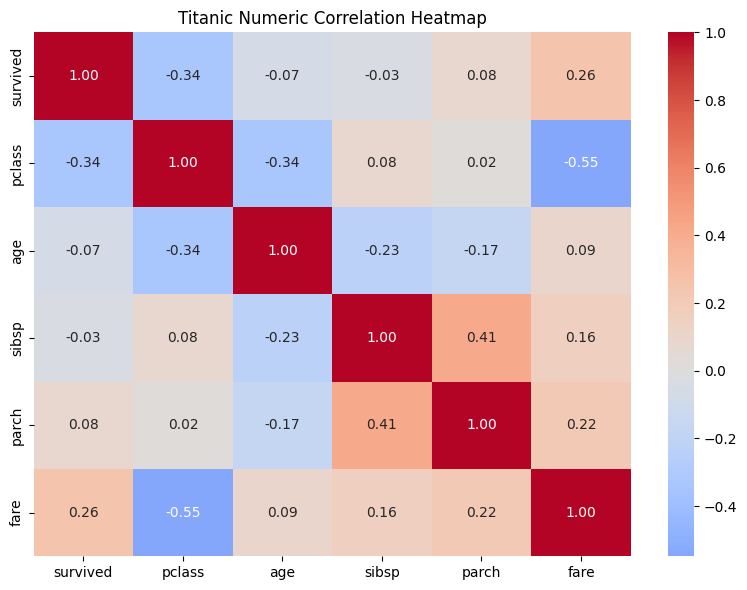

Two strongest correlations:


,feature_1,feature_2,correlation,abs_correlation
8,pclass,fare,-0.548193,0.548193
12,sibsp,parch,0.414542,0.414542


In [21]:
corr_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr = df[corr_cols].corr()
print("Required 6 x 6 correlation matrix:")
display(corr)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Titanic Numeric Correlation Heatmap")
fig.tight_layout()
fig.savefig(CHART_DIR / "05_correlation_heatmap.png", dpi=150)
plt.show()

pairs = []
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        a, b = corr_cols[i], corr_cols[j]
        value = corr.loc[a, b]
        pairs.append((a, b, value, abs(value)))

top_two = (
    pd.DataFrame(pairs, columns=["feature_1", "feature_2", "correlation", "abs_correlation"])
      .sort_values("abs_correlation", ascending=False)
      .head(2)
)

print("Two strongest correlations:")
display(top_two)


## 5. Multivariate data story — four distinct charts

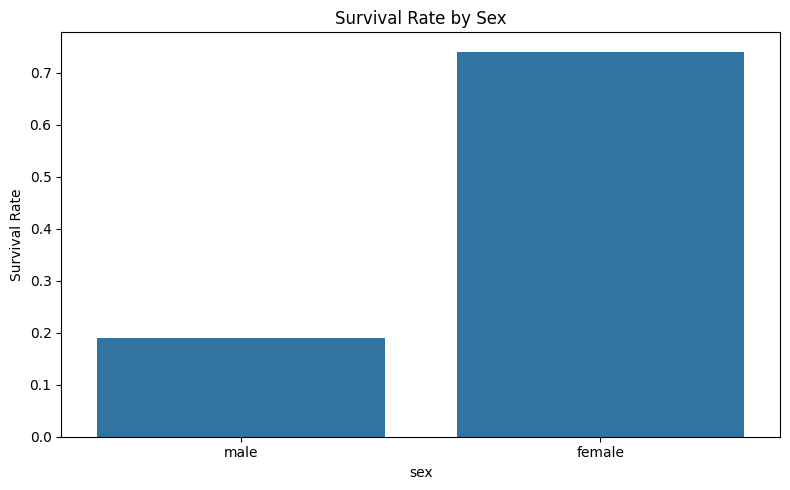

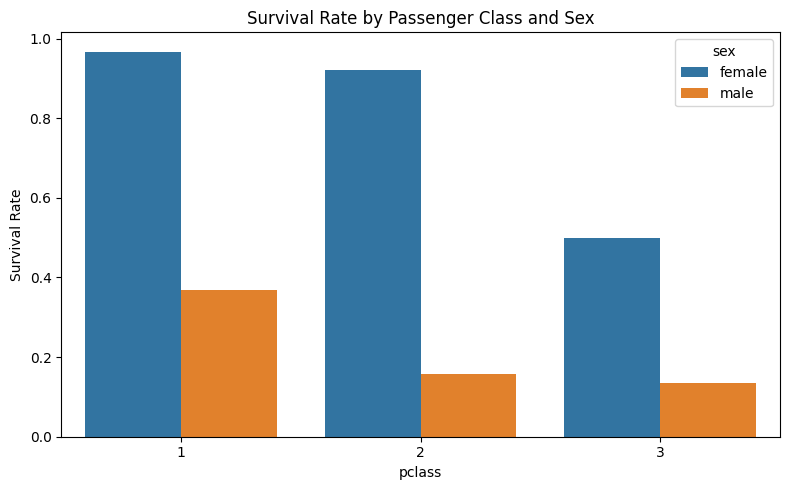

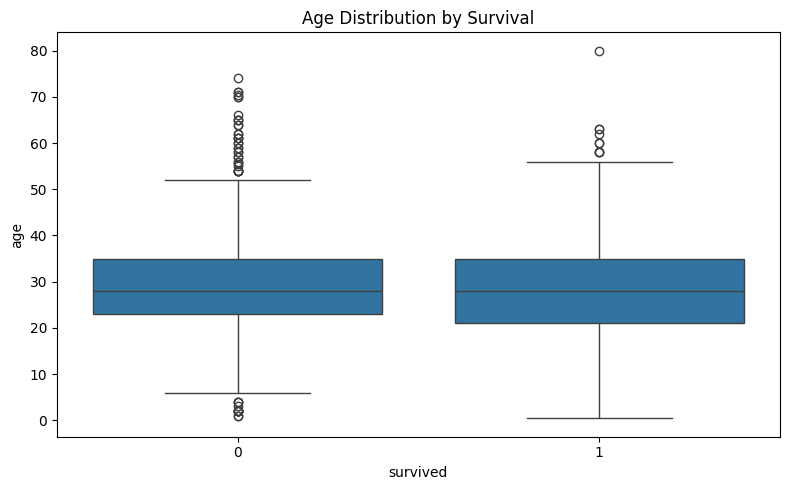

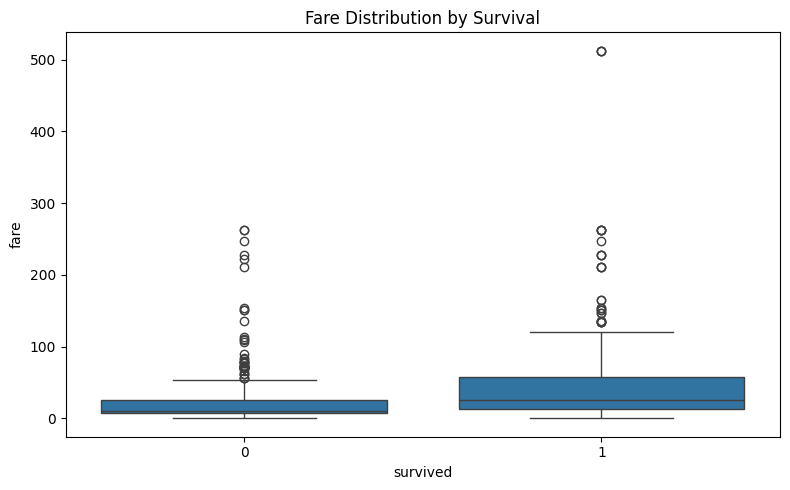

In [22]:

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df, x="sex", y="survived", errorbar=None, ax=ax)
ax.set_title("Survival Rate by Sex")
ax.set_ylabel("Survival Rate")
fig.tight_layout()
fig.savefig(CHART_DIR / "06_survival_by_sex.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df, x="pclass", y="survived", hue="sex", errorbar=None, ax=ax)
ax.set_title("Survival Rate by Passenger Class and Sex")
ax.set_ylabel("Survival Rate")
fig.tight_layout()
fig.savefig(CHART_DIR / "07_survival_by_sex_and_class.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="survived", y="age", ax=ax)
ax.set_title("Age Distribution by Survival")
fig.tight_layout()
fig.savefig(CHART_DIR / "08_age_by_survival.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="survived", y="fare", ax=ax)
ax.set_title("Fare Distribution by Survival")
fig.tight_layout()
fig.savefig(CHART_DIR / "09_fare_by_survival.png", dpi=150)
plt.show()


### Chart interpretations

**Chart 1 — Survival by sex:** The survival-rate comparison shows a clear difference between female and male passengers. This supports sex as an important predictor of survival in the Titanic dataset.

**Chart 2 — Survival by sex and passenger class:** Survival varies jointly by sex and passenger class rather than being explained by either variable alone. Passenger class provides additional context to the sex-based survival difference.

**Chart 3 — Age by survival:** The age distributions of survivors and non-survivors overlap, showing that age is informative but does not perfectly separate the two outcome groups.

**Chart 4 — Fare by survival:** Fare provides an additional socioeconomic signal alongside passenger class and can help explain differences in survival.

## 6. Exploratory standardization sanity check


In [27]:

standardizer = StandardScaler()

before = df[["age", "fare"]].agg(["mean", "std"]).T
scaled_values = standardizer.fit_transform(df[["age", "fare"]])

scaled_df = pd.DataFrame(scaled_values, columns=["age_z", "fare_z"], index=df.index)
after = scaled_df.agg(["mean", "std"]).T

print("Before standardization:")
display(before)

print("After standardization:")
display(after)

print("The transformed columns should have approximately mean 0 and standard deviation 1.")


Before standardization:


,mean,std
age,29.315152,12.984932
fare,32.096681,49.697504


After standardization:


,mean,std
age_z,2.717486e-16,1.000563
fare_z,1.398706e-16,1.000563


The transformed columns should have approximately mean 0 and standard deviation 1.


In [29]:
REPORT_DIR = Path('reports')
REPORT_DIR.mkdir(exist_ok=True)
REPORT_PATH = REPORT_DIR / 'eda_report.md'

top_corr_text = "; ".join(
    f"{row.feature_1} vs {row.feature_2}: r={row.correlation:.4f}"
    for row in top_two.itertuples()
)

report = f'''
# EDA Results

## Dataset profile
- Cleaned shape: {df.shape[0]} rows x {df.shape[1]} columns
- Age missing before cleaning: {age_missing_pct:.2f}%
- Embarked missing before cleaning: {missing_pct["embarked"]:.2f}%
- Embark_town missing before cleaning: {missing_pct["embark_town"]:.2f}%
- Deck missing before cleaning: {deck_missing_pct:.2f}%

## Missing-value decisions
- `age`: {age_missing_pct:.2f}% missing, so median imputation was used because the rate is between 5% and 30%.
- `embarked`: {missing_pct["embarked"]:.2f}% missing, so affected rows were dropped because the rate is below 5%.
- `embark_town`: {missing_pct["embark_town"]:.2f}% missing, so affected rows were dropped because the rate is below 5%; the column is redundant with `embarked`.
- `deck`: {deck_missing_pct:.2f}% missing, so the column was dropped because missingness is above 30% and reliable imputation would be inappropriate.

## Outliers and fare distribution
- Age IQR outliers: {age_outliers[0]}
- Fare IQR outliers: {fare_outliers[0]}
- Fare mean: {fare_mean:.4f}
- Fare median: {fare_median:.4f}
- Fare mode: {fare_mode:.4f}
- Fare distribution: {fare_shape}. This conclusion is based on the ordering of the mean, median, and mode.

## Strongest correlations
{top_corr_text}

## Multivariate chart interpretations
1. **Survival by sex:** The survival-rate comparison shows a clear difference between female and male passengers. This supports sex as an important predictor of survival.
2. **Survival by sex and passenger class:** Survival varies jointly by sex and passenger class. Passenger class provides additional context beyond the sex-based difference.
3. **Age by survival:** The age distributions overlap between survivors and non-survivors, showing that age is informative but not a perfect separator.
4. **Fare by survival:** Fare provides an additional socioeconomic signal alongside passenger class and can help explain differences in survival.

## Standardization check
The exploratory z-score transformation was applied only as an EDA sanity check. The modeling pipeline performs its own train-only scaling and does not reuse this exploratory transformation.
'''

REPORT_PATH.write_text(report, encoding="utf-8")
print("EDA report written to:", REPORT_PATH)


EDA report written to: reports/eda_report.md


## **PART-B — Predictive modeling, continuing from the same cleaned data**

## 7. Stratified train/test split — before preprocessing

In [34]:

# Split indices first so the exact same split can be reused.
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=50,
    stratify=df["survived"]
)

train_df = df.loc[train_idx].copy()
test_df = df.loc[test_idx].copy()

print("Training class balance:")
display(train_df["survived"].value_counts(normalize=True).rename("proportion"))

print("Test class balance:")
display(test_df["survived"].value_counts(normalize=True).rename("proportion"))

print(
    "Stratification is used because the target contains two classes. "
    "It keeps the survived/not-survived proportion approximately consistent "
    "between training and test sets, making model evaluation more representative."
)

feature_cols = ["pclass", "age", "sibsp", "parch", "fare", "sex", "embarked"]
target_col = "survived"

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]
y_train = train_df[target_col]
y_test = test_df[target_col]

numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked"]


Training class balance:


,proportion
survived,
0,0.61744
1,0.38256


Test class balance:


,proportion
survived,
0,0.617978
1,0.382022


Stratification is used because the target contains two classes. It keeps the survived/not-survived proportion approximately consistent between training and test sets, making model evaluation more representative.


## 8. Training-only preprocessing

In [35]:

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print(
    "Preprocessing is contained in a Pipeline/ColumnTransformer. "
    "When a model pipeline is fitted on X_train, the imputer, encoder, "
    "and scaler are fitted only on training data. X_test is only transformed."
)


Preprocessing is contained in a Pipeline/ColumnTransformer. When a model pipeline is fitted on X_train, the imputer, encoder, and scaler are fitted only on training data. X_test is only transformed.


## 9–10. Train and evaluate Logistic Regression, Decision Tree, and Random Forest

In [38]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=50),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=50),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=50
    )
}

fitted_models = {}
metrics_rows = {}

for name, estimator in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    metrics_rows[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_test, y_prob)
    }

    fitted_models[name] = pipe

metrics_df = pd.DataFrame(metrics_rows).T
print("Classification comparison:")
display(metrics_df.round(4))


Classification comparison:


,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.8146,0.7612,0.7500,0.7556,0.8609
Decision Tree,0.7921,0.8039,0.6029,0.6891,0.8176
Random Forest,0.8539,0.8750,0.7206,0.7903,0.8597


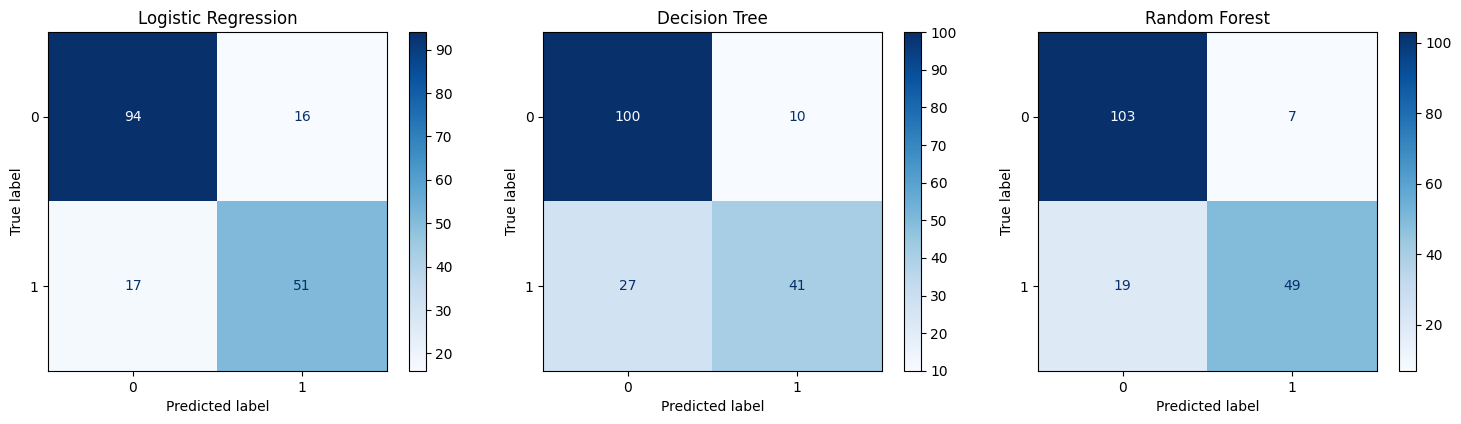

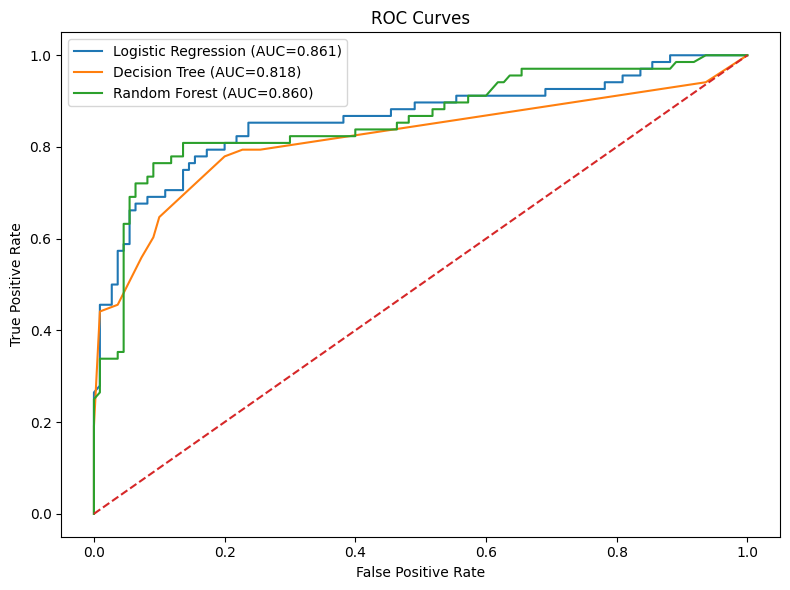

In [39]:

# Confusion matrices for all three models in one figure.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, pipe) in zip(axes, fitted_models.items()):
    ConfusionMatrixDisplay.from_estimator(
        pipe,
        X_test,
        y_test,
        ax=ax,
        cmap="Blues"
    )
    ax.set_title(name)

fig.tight_layout()
fig.savefig(CHART_DIR / "10_confusion_matrices.png", dpi=150)
plt.show()

# ROC curves for all three models in one figure.
fig, ax = plt.subplots(figsize=(8, 6))

for name, pipe in fitted_models.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_value = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_value:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves")
ax.legend()
fig.tight_layout()
fig.savefig(CHART_DIR / "11_roc_curves.png", dpi=150)
plt.show()


# decision tree visualization

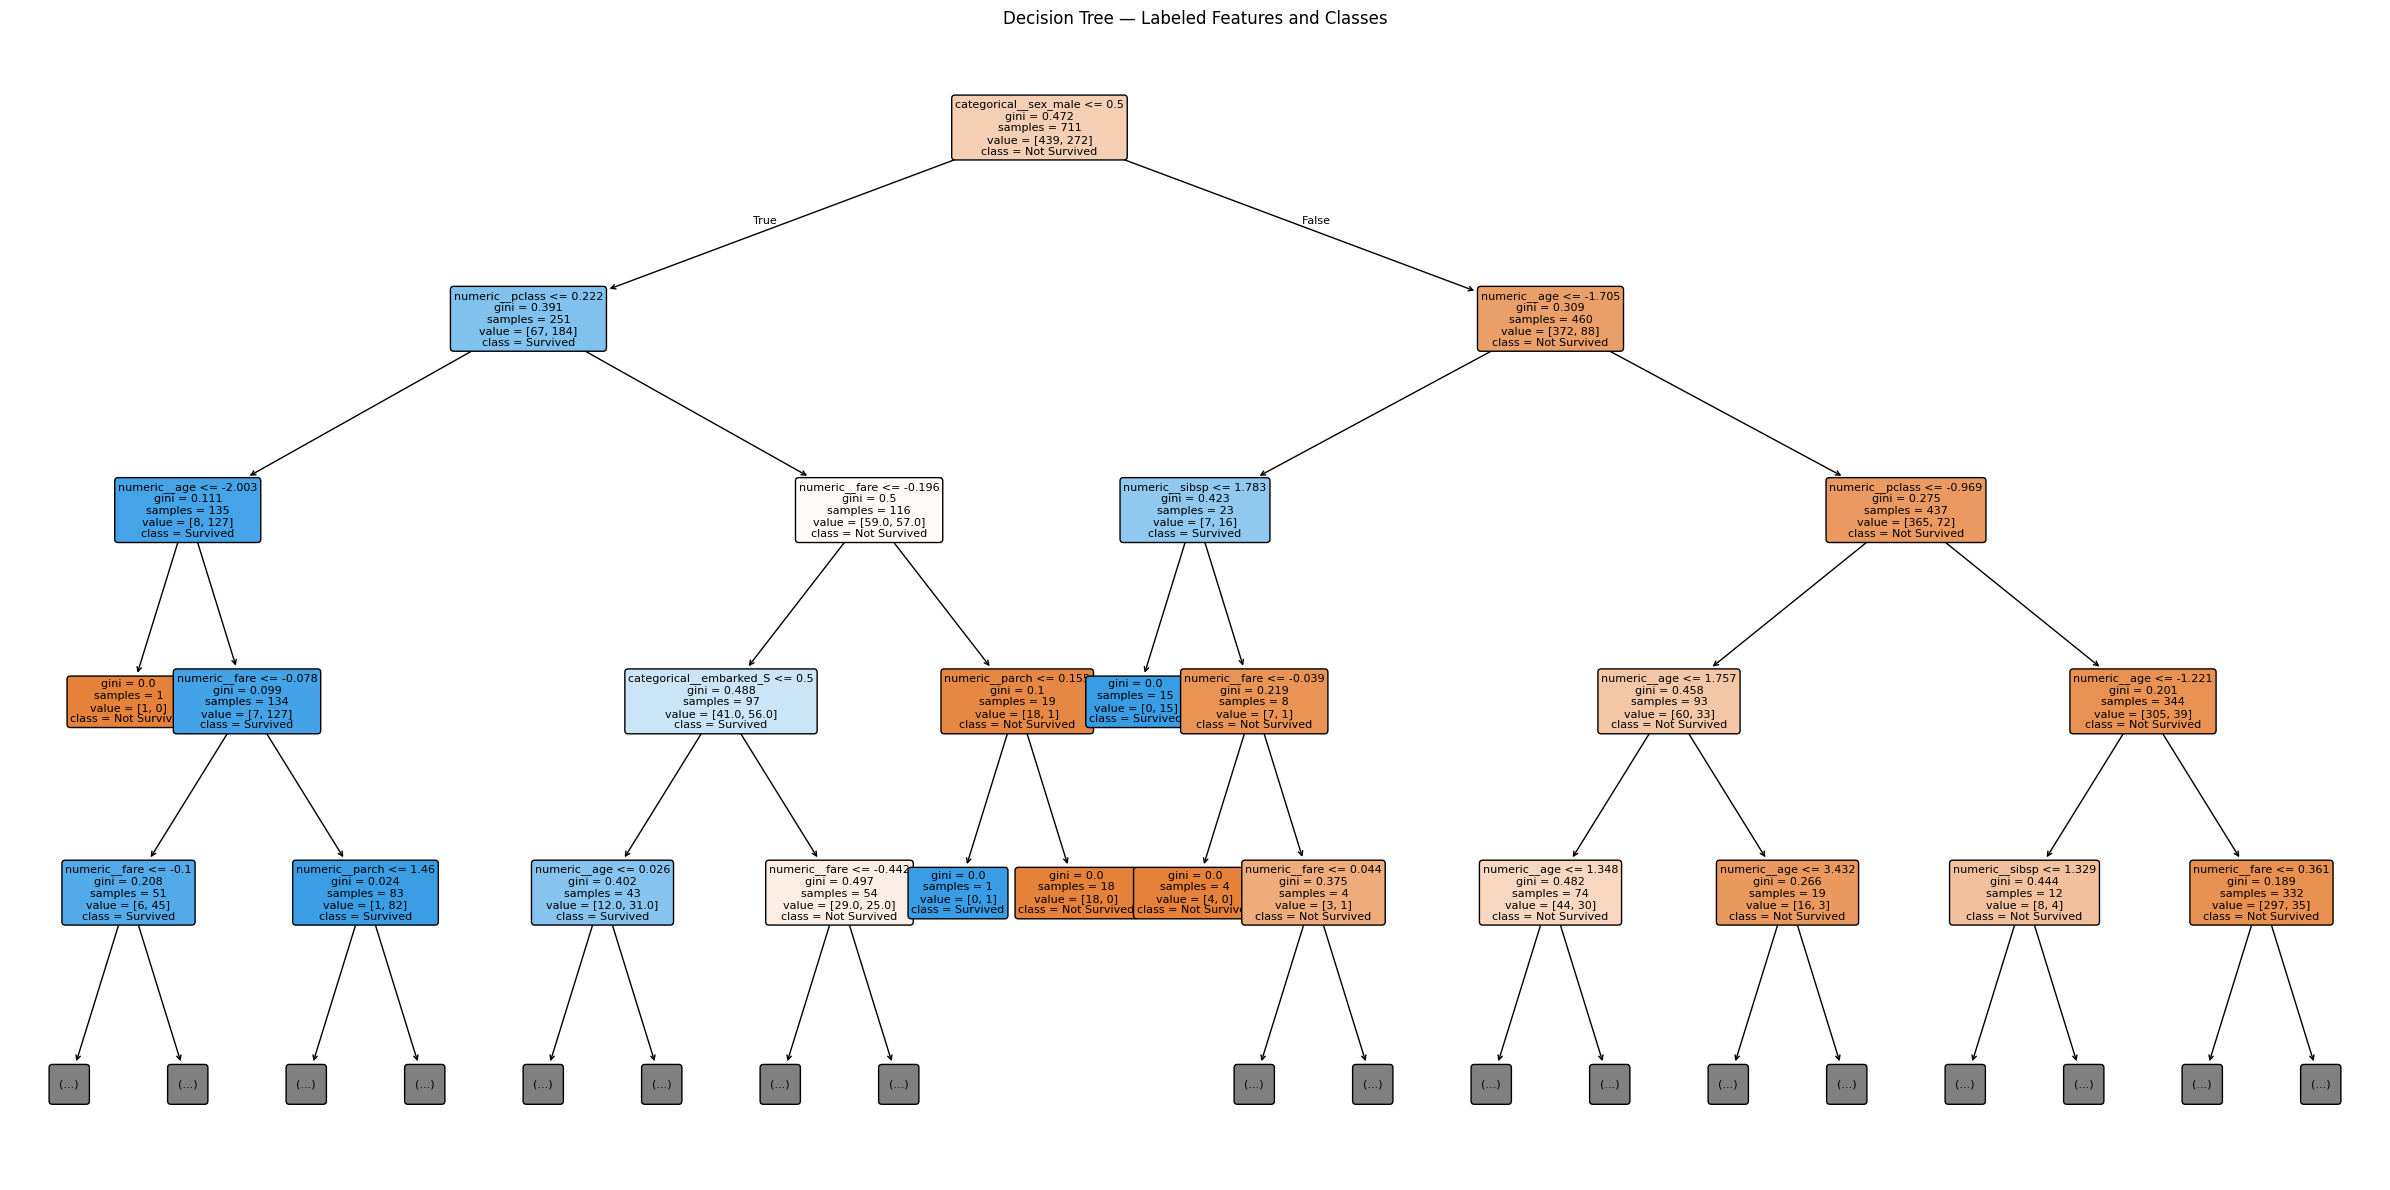

In [40]:

tree_pipe = fitted_models["Decision Tree"]
tree_model = tree_pipe.named_steps["model"]
tree_preprocessor = tree_pipe.named_steps["preprocessor"]

feature_names = tree_preprocessor.get_feature_names_out()

fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    max_depth=4,
    fontsize=8,
    ax=ax
)
ax.set_title("Decision Tree — Labeled Features and Classes")
fig.tight_layout()
fig.savefig(CHART_DIR / "12_decision_tree.png", dpi=150)
plt.show()


# class imbalance comparision

In [43]:
class_balance = (
    df["survived"]
      .value_counts()
      .sort_index()
      .rename(index={0: "Not Survived", 1: "Survived"})
      .to_frame("count")
)
class_balance["percentage"] = class_balance["count"] / len(df) * 100

display(class_balance)

# Use Logistic Regression for the three-way imbalance experiment.
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=50))
])

balanced_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=50
    ))
])

smote_model = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=50)),
    ("model", LogisticRegression(max_iter=2000, random_state=50))
])

imbalance_models = {
    "Baseline": baseline_model,
    "class_weight='balanced'": balanced_model,
    "SMOTE": smote_model
}

imbalance_rows = []

for name, pipe in imbalance_models.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    imbalance_rows.append({
        "Strategy": name,
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0)
    })

imbalance_df = pd.DataFrame(imbalance_rows).set_index("Strategy")

print("Imbalance strategy comparison:")
display(imbalance_df.round(4))

best_imbalance = imbalance_df["F1"].idxmax()
print(
    f"Best imbalance strategy by F1: {best_imbalance}. "
    "The selected strategy provides the strongest balance between precision and recall "
    "on the held-out test set."
)

,count,percentage
survived,,
Not Survived,549,61.754781
Survived,340,38.245219


Imbalance strategy comparison:


,Precision,Recall,F1
Strategy,,,
Baseline,0.7612,0.7500,0.7556
class_weight='balanced',0.7260,0.7794,0.7518
SMOTE,0.7361,0.7794,0.7571


Best imbalance strategy by F1: SMOTE. The selected strategy provides the strongest balance between precision and recall on the held-out test set.


## 12. Random Forest hyperparameter tuning with OOB score

In [45]:

rf_base = RandomForestClassifier(
    random_state=50,
    oob_score=True,
    bootstrap=True
)

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_base)
])

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10],
    "model__max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    refit=True
)

grid_search.fit(X_train, y_train)

best_rf_pipeline = grid_search.best_estimator_
best_rf_model = best_rf_pipeline.named_steps["model"]

print("Best parameters:")
print(grid_search.best_params_)
print(f"Best cross-validation F1: {grid_search.best_score_:.4f}")
print(f"OOB score: {best_rf_model.oob_score_:.4f}")


Best parameters:
{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__n_estimators': 300}
Best cross-validation F1: 0.7557
OOB score: 0.8158


## 13. Regression side-task — predict fare

In [46]:
# Predict fare using the other available passenger features.
# 'alive' is excluded because it is a redundant target-derived flag.
regression_features = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "sex",
    "embarked",
    "class",
    "who",
    "adult_male",
    "alone"
]

X_reg = df[regression_features]
y_reg = df["fare"]

X_reg_train = X_reg.loc[train_idx]
X_reg_test = X_reg.loc[test_idx]
y_reg_train = y_reg.loc[train_idx]
y_reg_test = y_reg.loc[test_idx]

reg_numeric = [
    "survived", "pclass", "age", "sibsp", "parch",
    "adult_male", "alone"
]
reg_categorical = ["sex", "embarked", "class", "who"]

reg_preprocessor = ColumnTransformer([
    (
        "numeric",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        reg_numeric
    ),
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]),
        reg_categorical
    )
])

regression_pipeline = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("model", LinearRegression())
])

regression_pipeline.fit(X_reg_train, y_reg_train)
reg_pred = regression_pipeline.predict(X_reg_test)

mae = mean_absolute_error(y_reg_test, reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, reg_pred))
r2 = r2_score(y_reg_test, reg_pred)

n = len(y_reg_test)
p = len(regression_pipeline.named_steps["preprocessor"].get_feature_names_out())

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"Adjusted R²: {adjusted_r2:.4f}")
print(f"Number of transformed predictors p: {p}")

MAE: 16.4415
RMSE: 38.5912
R²: 0.2319
Adjusted R²: 0.1449
Number of transformed predictors p: 18


## Final model comparsion and recommendation

In [48]:
# Re-evaluate the tuned Random Forest on the held-out test set.
rf_pred = best_rf_pipeline.predict(X_test)
rf_prob = best_rf_pipeline.predict_proba(X_test)[:, 1]

tuned_rf_metrics = {
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred, zero_division=0),
    "Recall": recall_score(y_test, rf_pred, zero_division=0),
    "F1": f1_score(y_test, rf_pred, zero_division=0),
    "AUC": roc_auc_score(y_test, rf_prob)
}

final_classification = metrics_df.copy()
final_classification.loc["Tuned Random Forest"] = tuned_rf_metrics

print("Classification metrics:")
display(final_classification.round(4))

regression_metrics = pd.DataFrame([{
    "Regression Model": "Linear Regression",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "Adjusted R2": adjusted_r2
}]).set_index("Regression Model")

print("Regression metrics:")
display(regression_metrics.round(4))

best_classifier = final_classification["F1"].idxmax()
best_classifier_f1 = final_classification.loc[best_classifier, "F1"]
best_classifier_auc = final_classification.loc[best_classifier, "AUC"]

print(
    f"Final recommendation: deploy {best_classifier}. "
    f"It has the highest F1 score in the evaluated classification set "
    f"({best_classifier_f1:.4f}) and an AUC of {best_classifier_auc:.4f}. "
    "F1 balances precision and recall, while AUC summarizes ranking ability across thresholds. "
    "The regression metrics are reported separately because classification and regression "
    "metrics are on different scales and are not directly comparable."
)


Classification metrics:


,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.8146,0.7612,0.7500,0.7556,0.8609
Decision Tree,0.7921,0.8039,0.6029,0.6891,0.8176
Random Forest,0.8539,0.8750,0.7206,0.7903,0.8597
Tuned Random Forest,0.8427,0.8571,0.7059,0.7742,0.8632


Regression metrics:


,MAE,RMSE,R2,Adjusted R2
Regression Model,,,,
Linear Regression,16.4415,38.5912,0.2319,0.1449


Final recommendation: deploy Random Forest. It has the highest F1 score in the evaluated classification set (0.7903) and an AUC of 0.8597. F1 balances precision and recall, while AUC summarizes ranking ability across thresholds. The regression metrics are reported separately because classification and regression metrics are on different scales and are not directly comparable.


## Save and relaod the complete pipeline

In [50]:
MODEL_DIR = Path('models')
MODEL_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODEL_DIR / 'best_pipeline.joblib'

# Choose the best classifier by held-out F1.
best_model_name = final_classification["F1"].idxmax()

if best_model_name == "Tuned Random Forest":
    full_pipeline = best_rf_pipeline
else:
    full_pipeline = fitted_models[best_model_name]

joblib.dump(full_pipeline, MODEL_PATH)
print("Saved complete pipeline to:", MODEL_PATH)

# Reload it and predict directly from raw, unpreprocessed input columns.
loaded_pipeline = joblib.load(MODEL_PATH)
reloaded_predictions = loaded_pipeline.predict(X_test.head(5))

print("Reloaded pipeline predictions:")
print(reloaded_predictions)

print("Reload test successful:", len(reloaded_predictions) == min(5, len(X_test)))

Saved complete pipeline to: models/best_pipeline.joblib
Reloaded pipeline predictions:
[1 0 0 1 0]
Reload test successful: True


In [54]:
ANALYTICS_DIR = Path('analytics')
ANALYTICS_DIR.mkdir(exist_ok=True)

# Save a final report containing the measured metrics for easy inclusion in README.
# One combined comparison table with separate classification and regression metric groups.
combined_rows = []

for model_name, row in final_classification.iterrows():
    combined_rows.append({
        "Model Type": "Classification",
        "Model": model_name,
        "Accuracy": row["Accuracy"],
        "Precision": row["Precision"],
        "Recall": row["Recall"],
        "F1": row["F1"],
        "AUC": row["AUC"],
        "MAE": np.nan,
        "RMSE": np.nan,
        "R2": np.nan,
        "Adjusted R2": np.nan
    })

combined_rows.append({
    "Model Type": "Regression",
    "Model": "Linear Regression",
    "Accuracy": np.nan,
    "Precision": np.nan,
    "Recall": np.nan,
    "F1": np.nan,
    "AUC": np.nan,
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "Adjusted R2": adjusted_r2
})

combined_comparison = pd.DataFrame(combined_rows)
display(combined_comparison.round(4))
combined_comparison.to_csv(ANALYTICS_DIR / "model_comparison.csv", index=False)

classification_table = final_classification.round(4).to_markdown()
regression_table = regression_metrics.round(4).to_markdown()
imbalance_table = imbalance_df.round(4).to_markdown()
combined_table = combined_comparison.round(4).to_markdown()

# Initialize hetero_conclusion as it was not defined in previous steps.
hetero_conclusion = ""

model_report = f'''
# Modeling Results

## Class balance
{class_balance.to_markdown()}

## Classification comparison
{classification_table}

## Imbalance comparison
{imbalance_table}

## Random Forest GridSearchCV
- Best parameters: {grid_search.best_params__ if False else grid_search.best_params_}
- Best CV F1: {grid_search.best_score_:.4f}
- OOB score: {best_rf_model.oob_score_:.4f}

## Regression
{regression_table}

## Combined model comparison
{combined_table}

## Heteroscedasticity
{hetero_conclusion}

## Final recommendation
Deploy **{best_classifier}** because it has the highest held-out F1 score ({best_classifier_f1:.4f}) among the evaluated classification models and an AUC of {best_classifier_auc:.4f}. F1 is useful here because it balances precision and recall rather than emphasizing only one. The regression results are presented separately because MAE, RMSE, R², and Adjusted R² are not directly comparable with classification metrics. The saved artifact is the complete preprocessing-plus-estimator pipeline and can accept raw input rows with the expected feature columns.
'''

(ANALYTICS_DIR / "MODELING_RESULTS.md").write_text(model_report, encoding="utf-8")
print("Modeling report written to:\n", ANALYTICS_DIR / "MODELING_RESULTS.md")

,Model Type,Model,Accuracy,Precision,Recall,F1,AUC,MAE,RMSE,R2,Adjusted R2
0,Classification,Logistic Regression,0.8146,0.7612,0.7500,0.7556,0.8609,NaN,NaN,NaN,NaN
1,Classification,Decision Tree,0.7921,0.8039,0.6029,0.6891,0.8176,NaN,NaN,NaN,NaN
2,Classification,Random Forest,0.8539,0.8750,0.7206,0.7903,0.8597,NaN,NaN,NaN,NaN
3,Classification,Tuned Random Forest,0.8427,0.8571,0.7059,0.7742,0.8632,NaN,NaN,NaN,NaN
4,Regression,Linear Regression,NaN,NaN,NaN,NaN,NaN,16.4415,38.5912,0.2319,0.1449


Modeling report written to:
 analytics/MODELING_RESULTS.md
